In [1]:
import esigmapy
import numpy as np
import matplotlib.pyplot as plt
from astropy.constants import GM_sun, c
from scipy.interpolate import CubicSpline
from scipy.signal import argrelextrema, savgol_filter
# from gwrompy.utils import find_t_location

No version information file '.version' found


In [2]:
mean_anomaly_array = np.linspace(-np.pi, np.pi, 50, endpoint=True)

# For eccentricity, $e = 0.1$

In [3]:
m1 = 20.
m2 = 20.
spin1z = 0.0
spin2z = 0.0
eccentricity = 0.1
mean_anomaly = np.pi
modes_to_use = [(2,2)]

distance = 400.

f_low = 20. 
delta_t = 1/2**16

In [4]:
t0 = GM_sun*(m1+ m2)/(c*c*c)

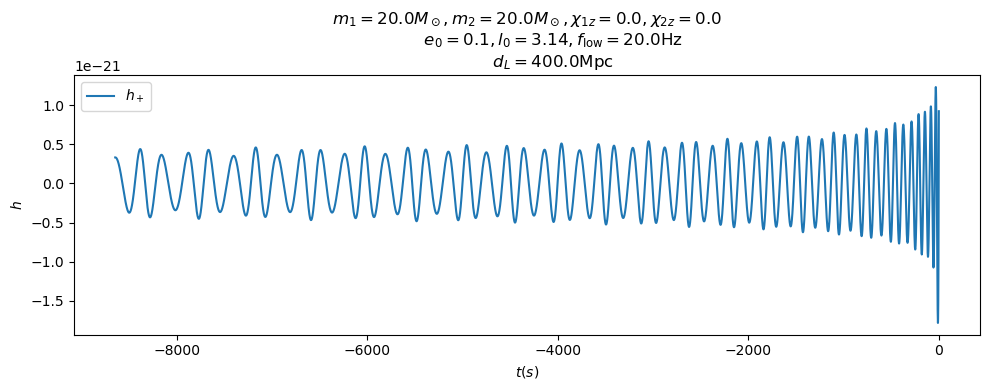

In [5]:
orb_vars, ref_mode = esigmapy.get_inspiral_esigma_modes(mass1=m1, 
                                        mass2=m2,
                                        spin1z=spin1z, 
                                        spin2z=spin2z,
                                        eccentricity=eccentricity,
                                        mean_anomaly=mean_anomaly,
                                        distance=distance,
                                        f_lower=f_low,
                                        delta_t=delta_t,
                                        include_conjugate_modes=False,
                                        modes_to_use=modes_to_use,
                                        return_orbital_params=['x'])

ref_signal = ref_mode[(2,2)]

plt.figure(figsize=(10,4))
plt.title(fr"""$m_1={m1} M_\odot, m_2={m2} M_\odot, \chi_{{1z}}={spin1z}, \chi_{{2z}}={spin2z}$ 
          $e_0={eccentricity}, l_0={mean_anomaly:.2f}, f_{{\rm{{low}}}}={f_low}\rm{{Hz}}$
          $d_L={distance}\rm{{Mpc}}$""")
# ref_signal.plot(label=r"$h_+$")
plt.plot(ref_signal.sample_times/t0, ref_signal.real(), label=r"$h_+$")
plt.xlabel(r"$t (s)$")
plt.ylabel(r"$h$")
plt.legend()
plt.tight_layout()

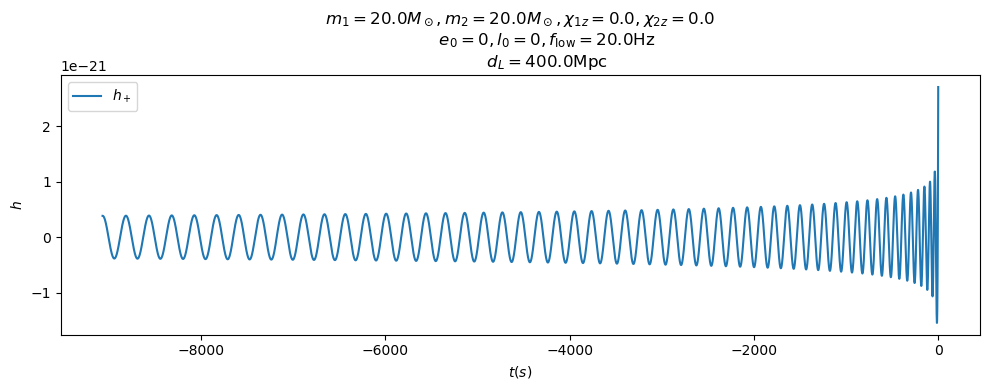

In [6]:
qc_orb_vars, qc_mode = esigmapy.get_inspiral_esigma_modes(mass1=m1, 
                                        mass2=m2,
                                        spin1z=spin1z, 
                                        spin2z=spin2z,
                                        eccentricity=0,
                                        mean_anomaly=0,
                                        distance=distance,
                                        f_lower=f_low,
                                        delta_t=delta_t,
                                        include_conjugate_modes=False,
                                        modes_to_use=modes_to_use,
                                        return_orbital_params=['x'])

qc_signal = qc_mode[(2,2)]

plt.figure(figsize=(10,4))
plt.title(fr"""$m_1={m1} M_\odot, m_2={m2} M_\odot, \chi_{{1z}}={spin1z}, \chi_{{2z}}={spin2z}$ 
          $e_0={0}, l_0={0}, f_{{\rm{{low}}}}={f_low}\rm{{Hz}}$
          $d_L={distance}\rm{{Mpc}}$""")
# ref_signal.plot(label=r"$h_+$")
plt.plot(qc_signal.sample_times/t0, qc_signal.real(), label=r"$h_+$")
plt.xlabel(r"$t (s)$")
plt.ylabel(r"$h$")
plt.legend()
plt.tight_layout()

In [7]:
t_of_x_spline = CubicSpline(orb_vars['x'].data, orb_vars['x'].sample_times/ t0)

x_val = np.linspace(orb_vars['x'].data.min(), 0.1, 20_000)

t_val = t_of_x_spline(x_val)
t_val = np.linspace(t_val[20], t_val[-1], 20_000)

ref_signal_amp = np.abs(ref_signal)
ref_signal_phase = np.unwrap(np.angle(ref_signal))

ref_signal_amp_spline = CubicSpline(ref_signal.sample_times / t0, ref_signal_amp)
ref_signal_phase_spline = CubicSpline(ref_signal.sample_times / t0, ref_signal_phase)

ref_signal_amp_reco = ref_signal_amp_spline(t_val)
ref_signal_phase_reco = ref_signal_phase_spline(t_val)

ref_signal_phase_reco = ref_signal_phase_reco - ref_signal_phase_reco[0]

ref_signal_reco = ref_signal_amp_reco * np.exp(1j * ref_signal_phase_reco)

In [30]:
t_of_x_spline = CubicSpline(qc_orb_vars['x'].data, qc_orb_vars['x'].sample_times/ t0)

x_val = np.linspace(qc_orb_vars['x'].data.min(), 0.1, 20_000)

t_val_circ = t_of_x_spline(x_val)
t_val_circ = np.linspace(t_val_circ[0], t_val_circ[-1], 20_000)

qc_signal_amp = np.abs(qc_signal)
qc_signal_phase = np.unwrap(np.angle(qc_signal))

qc_signal_amp_spline = CubicSpline(qc_signal.sample_times / t0, qc_signal_amp)
qc_signal_phase_spline = CubicSpline(qc_signal.sample_times / t0, qc_signal_phase)

qc_signal_amp_reco = qc_signal_amp_spline(t_val_circ)
qc_signal_phase_reco = qc_signal_phase_spline(t_val_circ)

qc_signal_phase_reco = qc_signal_phase_reco - qc_signal_phase_reco[0]

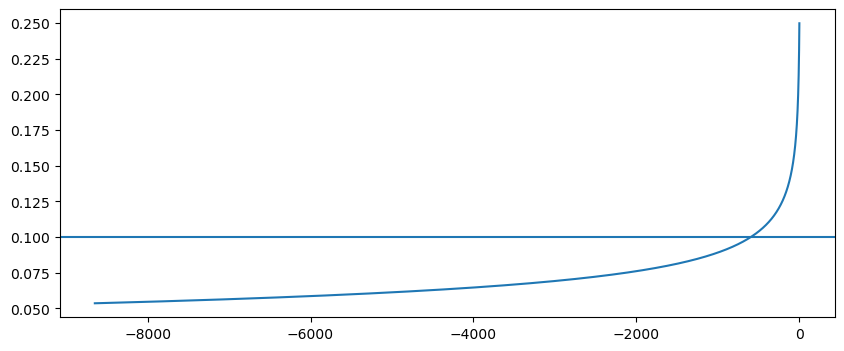

In [31]:
plt.figure(figsize=(10,4))
plt.plot(orb_vars['x'].sample_times/t0, orb_vars['x'])
plt.axhline(0.1)

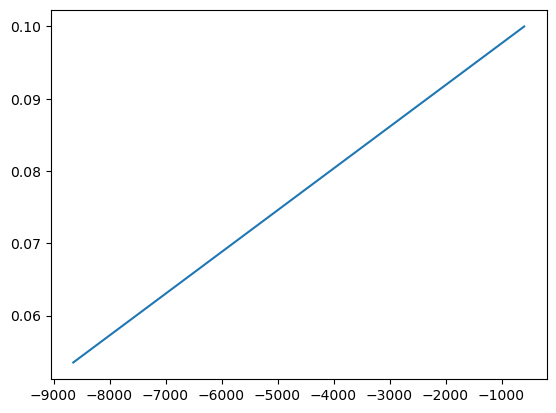

In [32]:
t_of_x_spline = CubicSpline(orb_vars['x'].data, orb_vars['x'].sample_times/t0)

x_val = np.linspace(orb_vars['x'].data.min(), 0.1, 20_000)

t_val = t_of_x_spline(x_val)
t_val = np.linspace(t_val[0], t_val[-1], 20_000)

plt.plot(t_val, x_val)

In [35]:
print(t_val, t_val_circ)

[-8647.92801424 -8647.52537127 -8647.12272829 ...  -596.27646911
  -595.87382613  -595.47118316] [-9068.93567562 -9068.51215898 -9068.08864235 ...  -599.87350646
  -599.44998983  -599.02647319]


In [11]:
ref_time = [i.value for i in ref_signal.sample_times / t0]

X_waveform = np.zeros((len(mean_anomaly_array), len(t_val)), dtype=complex)

ISCO_time  = {}

for i, mean_anomaly in enumerate(mean_anomaly_array):
    orb_vars_test, test_modes = esigmapy.get_inspiral_esigma_modes(
        mass1=m1, mass2=m2,
        spin1z=spin1z, spin2z=spin2z,
        eccentricity=eccentricity, mean_anomaly=mean_anomaly,
        distance=distance,
        f_lower=f_low, delta_t=delta_t,
        modes_to_use=modes_to_use,
        return_orbital_params=['x']
    )
    
    signal = test_modes[(2,2)]

    x_test = orb_vars_test['x']
    t_of_x_spline = CubicSpline(x_test.data, x_test.sample_times / t0)
    x_test_reconstructed = np.linspace(x_test.min(), 0.1, 20_000)

    test_time = [ i.value for i in signal.sample_times / t0]
    test_time_reconstructed = t_of_x_spline(x_test_reconstructed)
    test_time_reconstructed = np.linspace(test_time_reconstructed[0], test_time_reconstructed[-1], 20_000)

    ISCO_time[mean_anomaly] = test_time_reconstructed[-1]

    signal_amp = np.abs(signal)
    signal_phase = np.unwrap(np.angle(signal))
    
    amp_spline = CubicSpline(test_time, signal_amp)
    test_sample_amp = amp_spline(test_time_reconstructed)
    phase_spline = CubicSpline(test_time, signal_phase)
    test_sample_phase = phase_spline(test_time_reconstructed)
    
    amp_spline = CubicSpline(test_time_reconstructed, test_sample_amp)
    test_sample_amp = amp_spline(t_val)
    phase_spline = CubicSpline(test_time_reconstructed, test_sample_phase)
    test_sample_phase = phase_spline(t_val)
    
    test_sample_phase = test_sample_phase - test_sample_phase[0]

    test_sample_aligned = test_sample_amp * np.exp(1j * test_sample_phase)
    
    X_waveform[i, :] = test_sample_aligned

In [12]:
U, s, Vt = np.linalg.svd(X_waveform, full_matrices=False)

In [13]:
eccentric_harmonics = {}
indices = np.arange(10)
indices = np.delete(indices, 2)
indices

array([0, 1, 3, 4, 5, 6, 7, 8, 9])

In [14]:
eccentric_harmonics = {}

waveform_j2 = s[0] * Vt[0]
phase_j2 = np.unwrap(np.angle(waveform_j2))
dt = np.abs(ref_time[1] - ref_time[0])
freq_22_2 = np.gradient(phase_j2, dt) / np.pi
f_orb = 0.5 * freq_22_2

eccentric_harmonics[2] = waveform_j2

num_bases_to_check = 10
for i in range(1, num_bases_to_check):
    waveform = s[i] * Vt[i]
    phase = np.unwrap(np.angle(waveform))
    freq_22_j = np.gradient(phase, dt) / np.pi

    j_index = round(freq_22_j[0] / f_orb[0])

    if j_index > 0 and j_index not in eccentric_harmonics:
        print(f"SVD basis i={i} corresponds to harmonic j={j_index}")
        eccentric_harmonics[j_index] = waveform

sorted_harmonics = dict(sorted(eccentric_harmonics.items()))

SVD basis i=1 corresponds to harmonic j=3
SVD basis i=2 corresponds to harmonic j=1
SVD basis i=3 corresponds to harmonic j=4
SVD basis i=4 corresponds to harmonic j=5
SVD basis i=6 corresponds to harmonic j=6


In [15]:
qc_signal_reco = qc_signal_amp_reco * np.exp(1j * qc_signal_phase_reco)

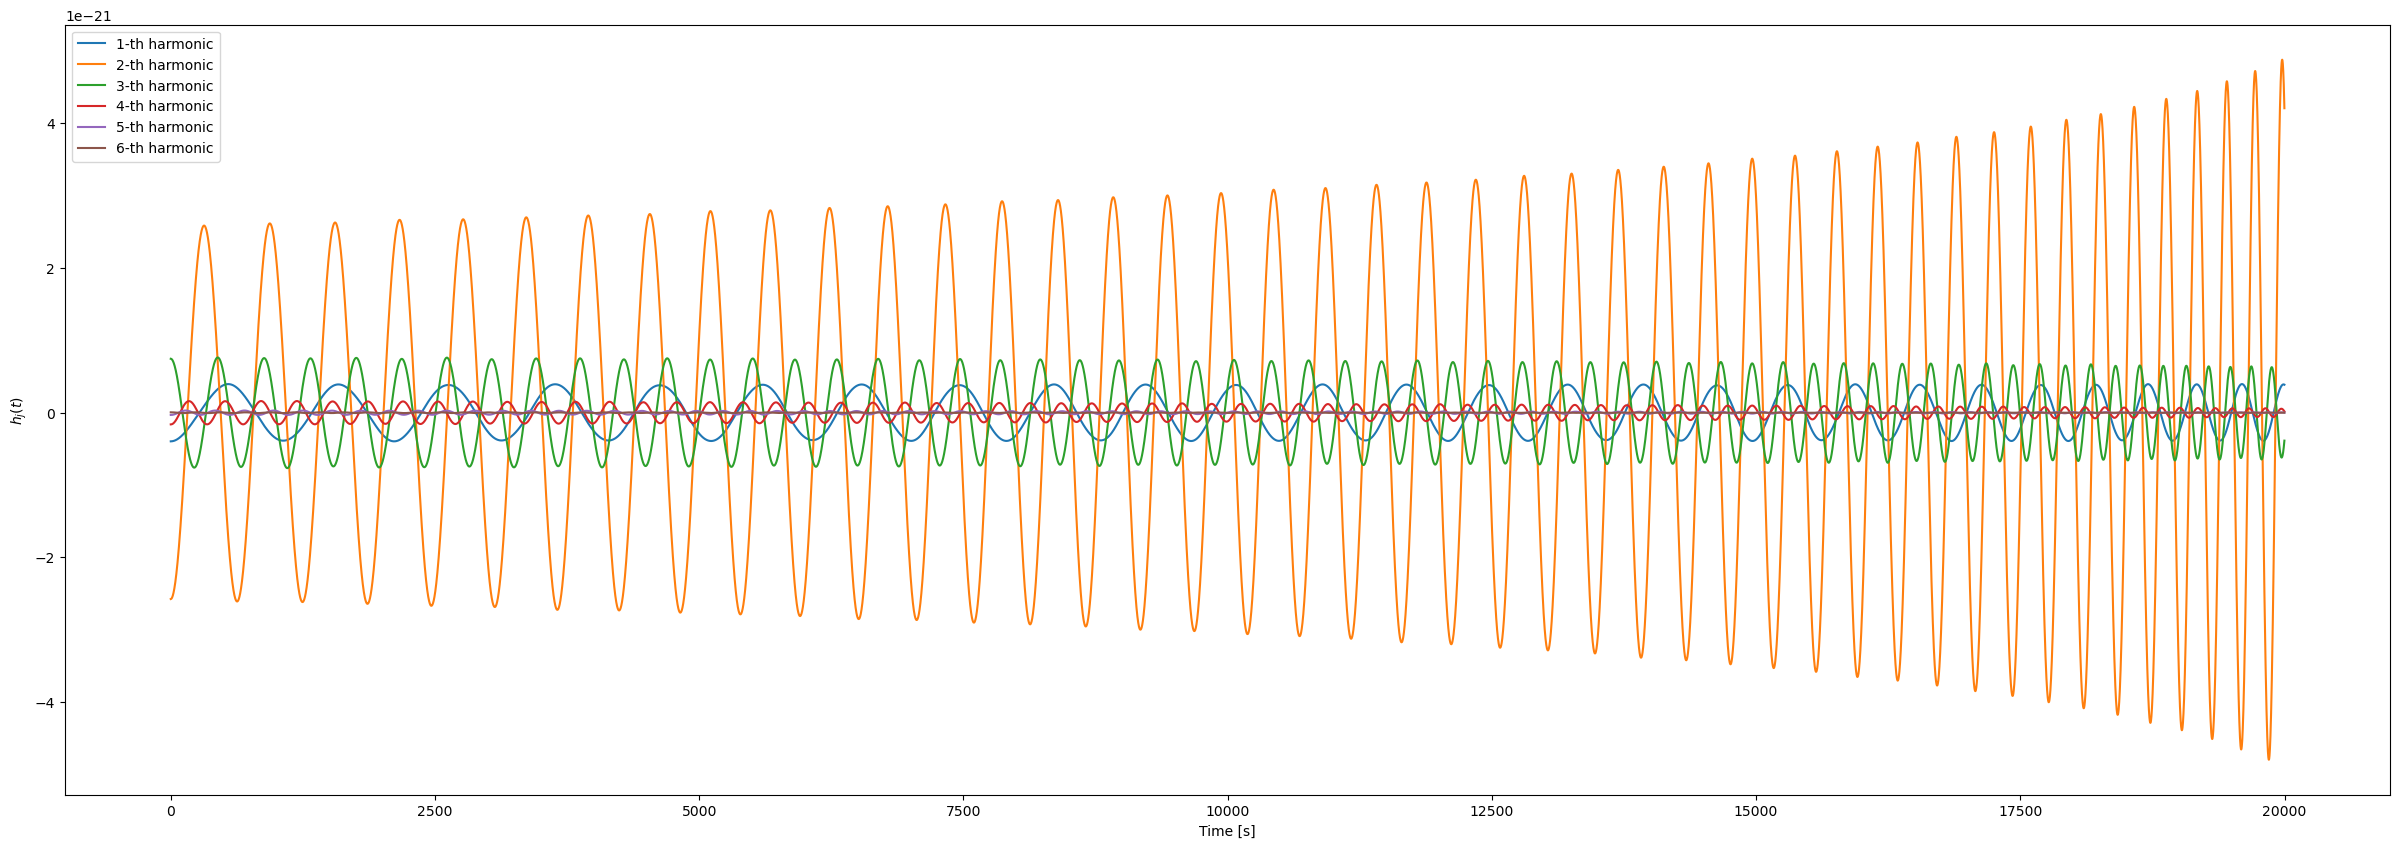

In [16]:
plt.figure(figsize=(30, 10))

for j_index, waveform in sorted_harmonics.items():
        plt.plot(waveform.real, label=f'{j_index}-th harmonic')
plt.ylabel('$h_j(t)$')
plt.xlabel('Time [s]')
plt.legend()
plt.show()

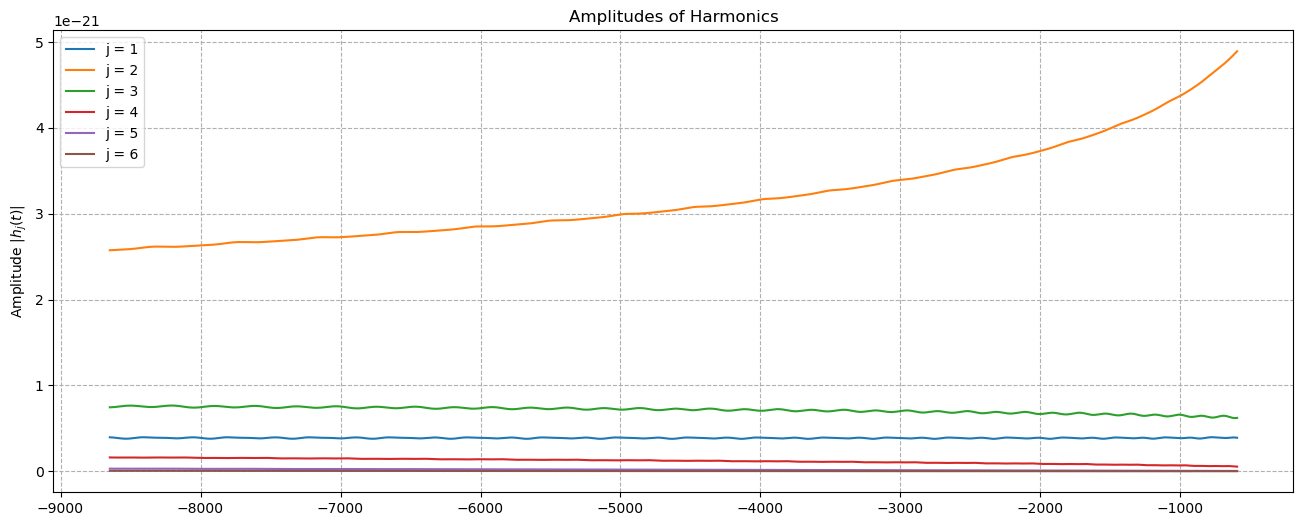

In [17]:
plt.figure(figsize=(16, 6))
for j_index, waveform in sorted_harmonics.items():
    amp = np.abs(waveform)
    plt.plot(t_val, amp, label=f'j = {j_index}')
plt.ylabel('Amplitude |$h_j(t)$|')
plt.title('Amplitudes of Harmonics')
plt.legend()
plt.grid(True, which="both", ls="--")

In [18]:
qc_signal_phase_reco[0]

0.0

In [38]:
from gwrompy.utils import find_y_at_x

In [39]:
phase_0 = find_y_at_x(t_val[0], t_val_circ, qc_signal_phase_reco)

In [40]:
phase_0

array(-10.51074871)

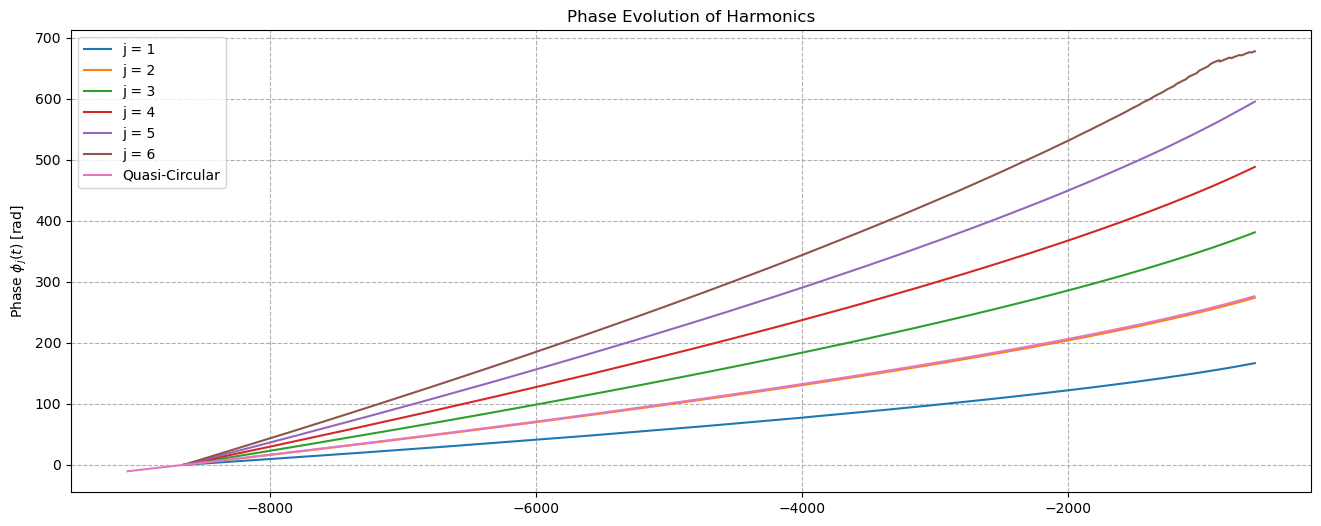

In [41]:
plt.figure(figsize=(16, 6))
for j_index, waveform in sorted_harmonics.items():
    phase = np.unwrap(np.angle(waveform))
    phase = phase - phase[0]
    plt.plot(t_val, -phase, label=f'j = {j_index}')
    # plt.plot(t_val, 1 / j_index * phase, label=f'j = {j_index}')

plt.plot(t_val_circ, -qc_signal_phase_reco + phase_0, label=f'Quasi-Circular')

plt.ylabel('Phase $\phi_j(t)$ [rad]')
plt.title('Phase Evolution of Harmonics')
plt.legend()
plt.grid(True, which="both", ls="--")

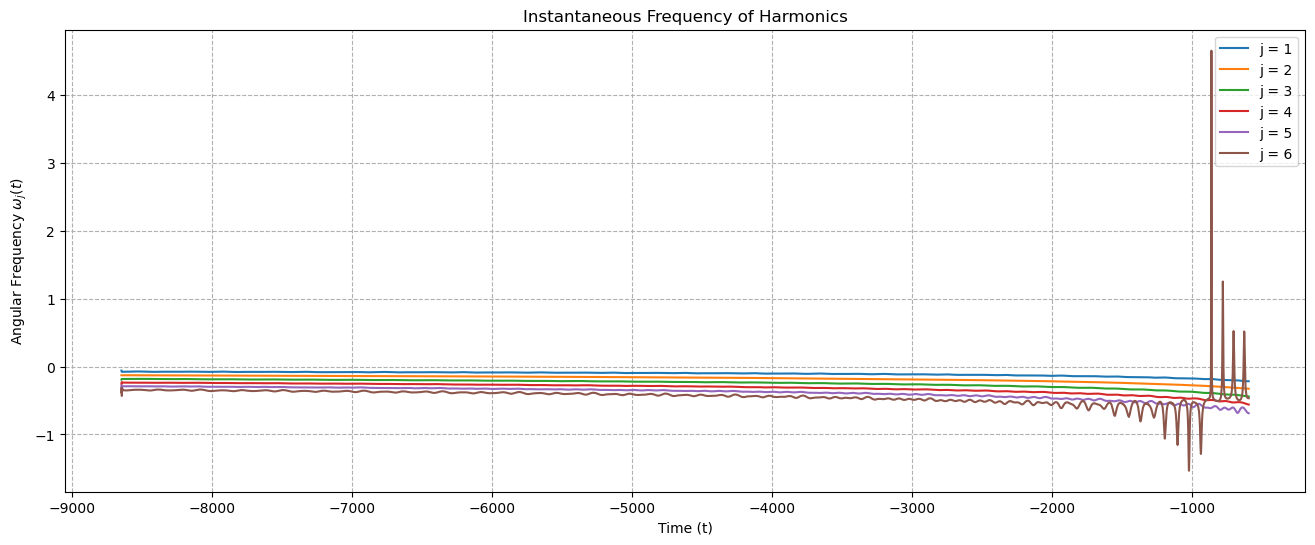

In [19]:
plt.figure(figsize=(16, 6))
for j_index, waveform in sorted_harmonics.items():
    phase = np.unwrap(np.angle(waveform))
    omega = np.gradient(phase, dt)
    plt.plot(t_val, omega, label=f'j = {j_index}')
plt.ylabel('Angular Frequency $\omega_j(t)$')
plt.title('Instantaneous Frequency of Harmonics')
plt.xlabel('Time (t)')
plt.legend()
plt.grid(True, which="both", ls="--")

In [20]:
def calculate_l2_error(h_original, h_recon):
    integrand_diff = np.abs(h_original - h_recon)**2
    integrand_orig = np.abs(h_original)**2
    numerator = np.sum(integrand_diff) * delta_t
    denominator = np.sum(integrand_orig) * delta_t
    return 0.5 * (numerator / denominator)

raw_basis_vectors = Vt[:5, :]
raw_errors = []

for i in range(50):
    original_waveform = X_waveform[i, :]
    
    coeffs_raw = np.dot(original_waveform, raw_basis_vectors.conj().T)
    recon_raw = np.dot(coeffs_raw, raw_basis_vectors)
    raw_errors.append(calculate_l2_error(original_waveform, recon_raw))

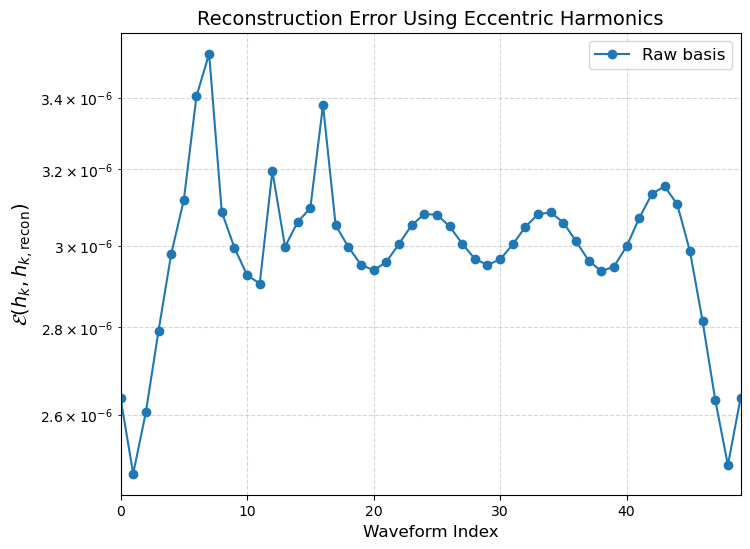

In [21]:
plt.figure(figsize=(8, 6))
plt.semilogy(range(50), raw_errors, 'o-', label='Raw basis', color='C0')
plt.xlabel('Waveform Index', fontsize=12)
plt.ylabel(r'$\mathcal{E}(h_k, h_{k, \text{recon}})$', fontsize=14)
plt.title('Reconstruction Error Using Eccentric Harmonics', fontsize=14)
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.legend(fontsize=12)
# plt.ylim(bottom=1e-6)
plt.xlim(0, 50 - 1)
plt.show()

# Computing $\phi_{22}^{\text{avg}}$ from the integration of the average of (2,2) mode angular frequency, $\omega_{22}$ (which in turn is obtained from taking average of the interpolants of extrema of raw $\omega_{22}$)

In [22]:
h_22 = ref_signal_reco
t = t_val
dt = np.abs(t[1] - t[0])
phase_22 = np.unwrap(np.angle(h_22))
omega_22 = np.gradient(phase_22, dt)
omega_orb = omega_22 / 2.0

# window_length = 51
# poly_order = 3 

# if len(omega_orb) < window_length:
#     window_length = len(omega_orb) - 1 if len(omega_orb) % 2 == 0 else len(omega_orb)
#     if window_length < 3:
#          omega_orb_smoothed = omega_orb
#     else:
#          omega_orb_smoothed = savgol_filter(omega_orb, window_length, poly_order)
# else:
#     omega_orb_smoothed = savgol_filter(omega_orb, window_length, poly_order)

# max_indices = argrelextrema(omega_orb_smoothed, np.greater)[0]
max_indices = argrelextrema(omega_orb, np.greater)[0]

# min_indices = argrelextrema(omega_orb_smoothed, np.less)[0]
min_indices = argrelextrema(omega_orb, np.less)[0]
min_indices = min_indices[2:]

t_p = t[max_indices]
omega_orb_p = omega_orb[max_indices]

t_a = t[min_indices]
omega_orb_a = omega_orb[min_indices]

# t_merger = t[-1]
# omega_orb_merger = omega_orb[-1]

# t_p = np.append(t_p, t_merger)
# omega_orb_p = np.append(omega_orb_p, omega_orb_merger)

# t_a = np.append(t_a, t_merger)
# omega_orb_a = np.append(omega_orb_a, omega_orb_merger)

sort_p = np.argsort(t_p)
t_p = t_p[sort_p]
omega_orb_p = omega_orb_p[sort_p]

sort_a = np.argsort(t_a)
t_a = t_a[sort_a]
omega_orb_a = omega_orb_a[sort_a]

spline_p = CubicSpline(t_p, omega_orb_p)
spline_a = CubicSpline(t_a, omega_orb_a)

omega_orb_p_cont = spline_p(t)
omega_orb_a_cont = spline_a(t)

omega_orb_avg = (omega_orb_p_cont + omega_orb_a_cont) / 2.0

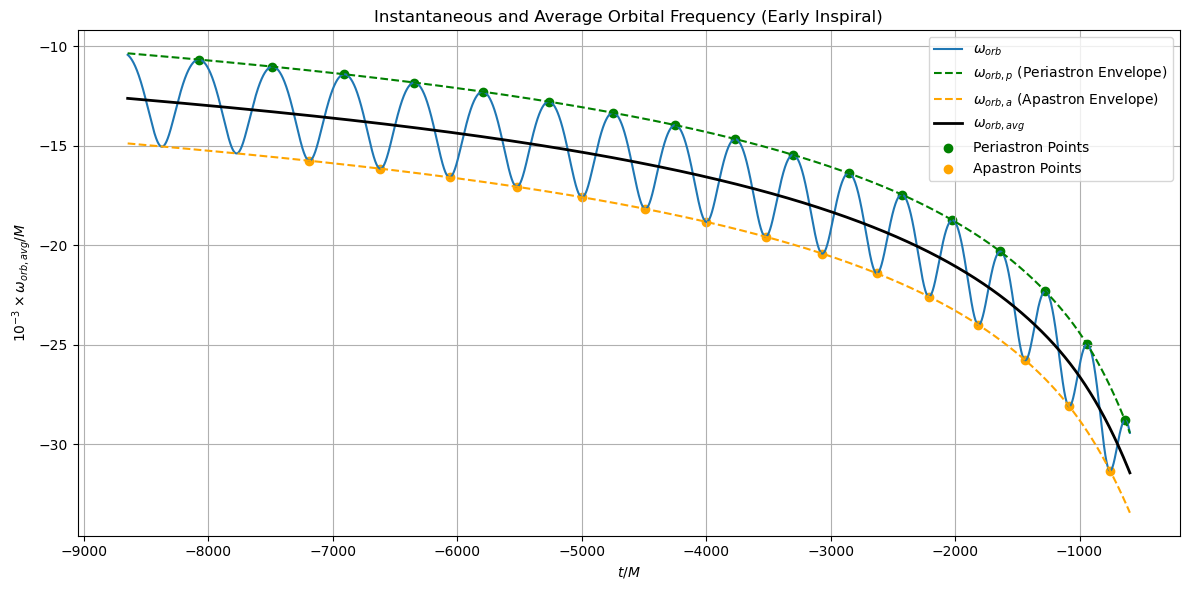

The average orbital frequency $\omega_{orb,avg}$ is a numpy array (length 20000) of monotonic frequency values in units of 1/M.


In [23]:
plt.figure(figsize=(12, 6))
plt.plot(t, omega_orb * 1e3, label=r'$\omega_{orb}$') # Scale for better visibility
plt.plot(t, omega_orb_p_cont * 1e3, label=r'$\omega_{orb,p}$ (Periastron Envelope)', linestyle='--', color='green')
plt.plot(t, omega_orb_a_cont * 1e3, label=r'$\omega_{orb,a}$ (Apastron Envelope)', linestyle='--', color='orange')
plt.plot(t, omega_orb_avg * 1e3, label=r'$\omega_{orb,avg}$', color='black', linewidth=2)
plt.scatter(t[max_indices], omega_orb[max_indices] * 1e3, color='green', marker='o', label='Periastron Points')
plt.scatter(t[min_indices], omega_orb[min_indices] * 1e3, color='orange', marker='o', label='Apastron Points')
plt.xlabel(r'$t/M$')
plt.ylabel(r'$10^{-3} \times \omega_{orb, avg}/M$')
plt.title('Instantaneous and Average Orbital Frequency (Early Inspiral)')
# plt.xlim(t[0], t[-1])
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

print(rf"The average orbital frequency $\omega_{{orb,avg}}$ is a numpy array (length {len(omega_orb_avg)}) of monotonic frequency values in units of 1/M.")

In [24]:
from scipy.signal import detrend

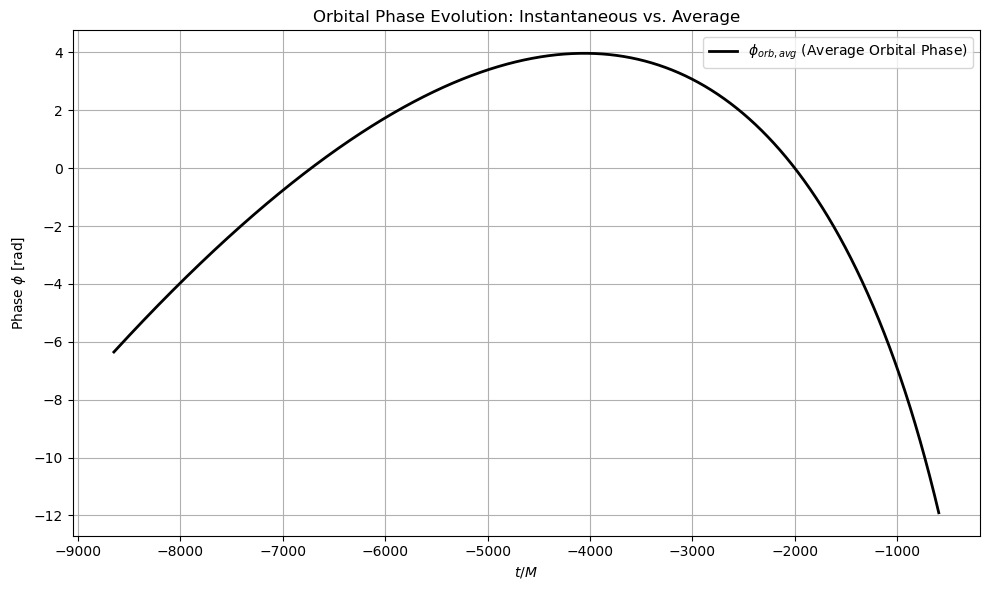

In [25]:
phi_orb = np.cumsum(omega_orb * dt)
phi_orb = phi_orb - phi_orb[0]

window_length = 51
poly_order = 3 

if len(omega_orb) < window_length:
    window_length = len(omega_orb) - 1 if len(omega_orb) % 2 == 0 else len(omega_orb)
    if window_length < 3:
         omega_orb_smoothed = omega_orb
    else:
         omega_orb_smoothed = savgol_filter(omega_orb, window_length, poly_order)
else:
    omega_orb_smoothed = savgol_filter(omega_orb, window_length, poly_order)

max_indices = argrelextrema(omega_orb_smoothed, np.greater)[0]
min_indices = argrelextrema(omega_orb_smoothed, np.less)[0]

t_p = t[max_indices]
omega_orb_p = omega_orb[max_indices]

t_a = t[min_indices]
omega_orb_a = omega_orb[min_indices]

t_merger = t[-1]
omega_orb_merger = omega_orb[-1]

sort_p = np.argsort(t_p)
t_p = t_p[sort_p]
omega_orb_p = omega_orb_p[sort_p]

sort_a = np.argsort(t_a)
t_a = t_a[sort_a]
omega_orb_a = omega_orb_a[sort_a]

spline_p = CubicSpline(t_p, omega_orb_p)
spline_a = CubicSpline(t_a, omega_orb_a)

omega_orb_p_cont = spline_p(t)
omega_orb_a_cont = spline_a(t)

omega_orb_avg = (omega_orb_p_cont + omega_orb_a_cont) / 2.0

phi_orb_avg = np.cumsum(omega_orb_avg * dt)
phi_orb_avg = phi_orb_avg - phi_orb_avg[0]

plt.figure(figsize=(10, 6))

phi_detrended = detrend(phi_orb)
phi_orb_avg_detrend = detrend(phi_orb_avg)

# plt.plot(t, phi_orb_avg, label=r'$\phi_{orb,avg}$ (Average Orbital Phase)', color='black', linewidth=2)
plt.plot(t, phi_orb_avg_detrend, label=r'$\phi_{orb,avg}$ (Average Orbital Phase)', color='black', linewidth=2)

# plt.plot(t, phi_orb, label=r'$\phi_{orb}$ (Instantaneous Orbital Phase)', linestyle='--', color='gray', alpha=0.6)

plt.xlabel(r'$t/M$')
plt.ylabel(r'Phase $\phi$ [rad]')
plt.title('Orbital Phase Evolution: Instantaneous vs. Average')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# Computing $\phi_{22}^{\prime \text{ } \text{avg}}$ = $\phi_{22}^{\text{circ}}$ + $\phi_{\text{res}}$. And $\phi_{\text{res}}$ is obatined from taking average of the interpolants of extremas of $\Delta \phi_1 = \phi_{22} - \phi_{22}^{\text{circ}}$

In [26]:
t = t_val
phase_22 = np.unwrap(np.angle(ref_signal_reco))
phase_22_circ = qc_signal_phase_reco 
dt = np.abs(t[1] - t[0])

Delta_phi_1 = phase_22 - phase_22_circ

window_length = 51 
poly_order = 3 

if len(Delta_phi_1) < window_length:
    window_length = len(Delta_phi_1) - 1 if len(Delta_phi_1) % 2 == 0 else len(Delta_phi_1)
    if window_length < 3:
         Delta_phi_1_smoothed = Delta_phi_1
    else:
         Delta_phi_1_smoothed = savgol_filter(Delta_phi_1, window_length, poly_order)
else:
    Delta_phi_1_smoothed = savgol_filter(Delta_phi_1, window_length, poly_order)

max_indices = argrelextrema(Delta_phi_1_smoothed, np.greater)[0]
min_indices = argrelextrema(Delta_phi_1_smoothed, np.less)[0]

t_max = t[max_indices]
Delta_phi_1_max = Delta_phi_1[max_indices]
t_min = t[min_indices]
Delta_phi_1_min = Delta_phi_1[min_indices]

t_start, t_end = t[0], t[-1]
Delta_phi_1_start, Delta_phi_1_end = Delta_phi_1[0], Delta_phi_1[-1]

t_max = np.insert(t_max, 0, t_start)
Delta_phi_1_max = np.insert(Delta_phi_1_max, 0, Delta_phi_1_start)
t_max = np.append(t_max, t_end)
Delta_phi_1_max = np.append(Delta_phi_1_max, Delta_phi_1_end)

t_min = np.insert(t_min, 0, t_start)
Delta_phi_1_min = np.insert(Delta_phi_1_min, 0, Delta_phi_1_start)
t_min = np.append(t_min, t_end)
Delta_phi_1_min = np.append(Delta_phi_1_min, Delta_phi_1_end)

t_max = t_max[np.argsort(t_max)]
Delta_phi_1_max = Delta_phi_1_max[np.argsort(t_max)]
t_min = t_min[np.argsort(t_min)]
Delta_phi_1_min = Delta_phi_1_min[np.argsort(t_min)]


spline_max = CubicSpline(t_max, Delta_phi_1_max)
spline_min = CubicSpline(t_min, Delta_phi_1_min)

Delta_phi_1_max_cont = spline_max(t)
Delta_phi_1_min_cont = spline_min(t)

phi_res = (Delta_phi_1_max_cont + Delta_phi_1_min_cont) / 2.0

phi_prime_22_avg = phase_22_circ + phi_res

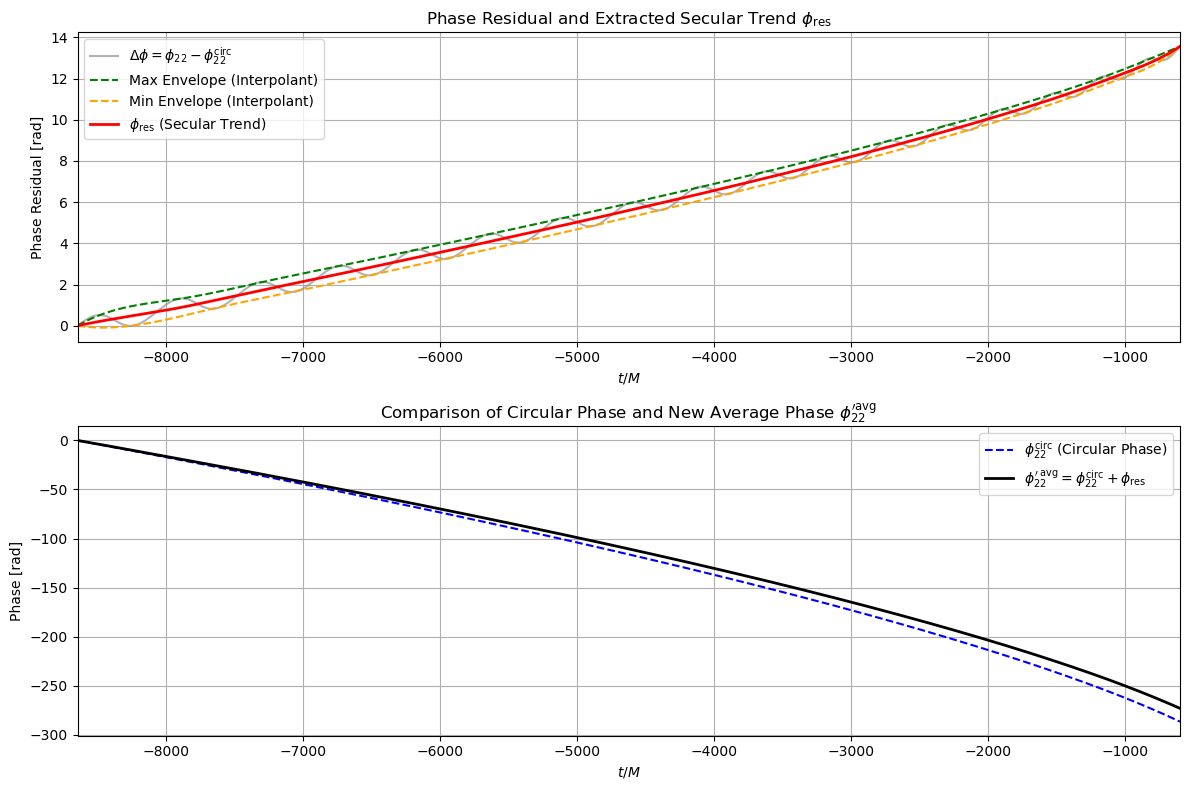

In [27]:

plt.figure(figsize=(12, 8))
plt.subplot(2, 1, 1)
plt.plot(t, Delta_phi_1, label=r'$\Delta \phi = \phi_{22} - \phi_{22}^{\mathrm{circ}}$', color='gray', alpha=0.6)
plt.plot(t, Delta_phi_1_max_cont, label='Max Envelope (Interpolant)', linestyle='--', color='green')
plt.plot(t, Delta_phi_1_min_cont, label='Min Envelope (Interpolant)', linestyle='--', color='orange')
plt.plot(t, phi_res, label=r'$\phi_{\mathrm{res}}$ (Secular Trend)', color='red', linewidth=2)
plt.xlabel(r'$t/M$')
plt.ylabel(r'Phase Residual [rad]')
plt.title(r'Phase Residual and Extracted Secular Trend $\phi_{\mathrm{res}}$') 
plt.xlim(t[0], t[-1])
plt.legend()
plt.grid(True)

plt.subplot(2, 1, 2)
plt.plot(t, phase_22_circ, label=r'$\phi_{22}^{\mathrm{circ}}$ (Circular Phase)', color='blue', linestyle='--')
plt.plot(t, phi_prime_22_avg, label=r'$\phi_{22}^{\prime\text{ }\mathrm{avg}} = \phi_{22}^{\mathrm{circ}} + \phi_{\mathrm{res}}$', color='black', linewidth=2)
plt.xlabel(r'$t/M$')
plt.ylabel(r'Phase [rad]')
plt.title(r'Comparison of Circular Phase and New Average Phase $\phi_{22}^{\prime\mathrm{avg}}$') 
plt.xlim(t[0], t[-1])
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# For eccentricity, $e = 0.5$

In [28]:
m1 = 20.
m2 = 20.
spin1z = 0.0
spin2z = 0.0
eccentricity = 0.5
mean_anomaly = np.pi
modes_to_use = [(2,2)]

distance = 400.

f_low = 10. 
delta_t = 1/2**16

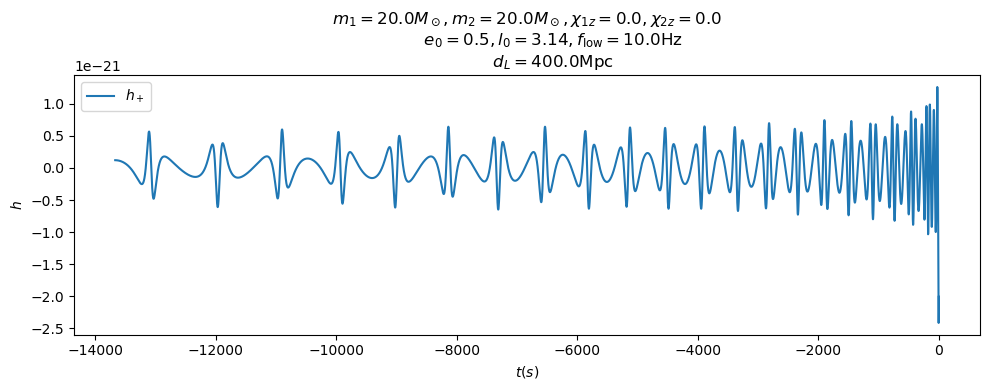

In [29]:
orb_vars, ref_mode = esigmapy.get_inspiral_esigma_modes(mass1=m1, 
                                        mass2=m2,
                                        spin1z=spin1z, 
                                        spin2z=spin2z,
                                        eccentricity=eccentricity,
                                        mean_anomaly=mean_anomaly,
                                        distance=distance,
                                        f_lower=f_low,
                                        delta_t=delta_t,
                                        include_conjugate_modes=False,
                                        modes_to_use=modes_to_use,
                                        return_orbital_params=['x'])

ref_signal = ref_mode[(2,2)]

plt.figure(figsize=(10,4))
plt.title(fr"""$m_1={m1} M_\odot, m_2={m2} M_\odot, \chi_{{1z}}={spin1z}, \chi_{{2z}}={spin2z}$ 
          $e_0={eccentricity}, l_0={mean_anomaly:.2f}, f_{{\rm{{low}}}}={f_low}\rm{{Hz}}$
          $d_L={distance}\rm{{Mpc}}$""")
# ref_signal.plot(label=r"$h_+$")
plt.plot(ref_signal.sample_times/t0, ref_signal.real(), label=r"$h_+$")
plt.xlabel(r"$t (s)$")
plt.ylabel(r"$h$")
plt.legend()
plt.tight_layout()

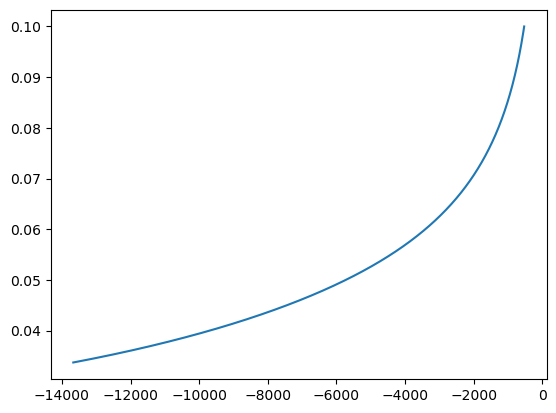

In [30]:
t_of_x_spline = CubicSpline(orb_vars['x'].data, orb_vars['x'].sample_times/t0)

x_val = np.linspace(orb_vars['x'].data.min(), 0.1, 20000)

t_val = t_of_x_spline(x_val)

plt.plot(t_val, x_val)

In [31]:
ref_time = [i.value for i in ref_signal.sample_times / t0]

X_waveform = np.zeros((len(mean_anomaly_array), len(t_val)), dtype=complex)

for i, mean_anomaly in enumerate(mean_anomaly_array):
    orb_vars_test, test_modes = esigmapy.get_inspiral_esigma_modes(
        mass1=m1, mass2=m2,
        spin1z=spin1z, spin2z=spin2z,
        eccentricity=eccentricity, mean_anomaly=mean_anomaly,
        distance=distance,
        f_lower=f_low, delta_t=delta_t,
        modes_to_use=modes_to_use,
        return_orbital_params=['x']
    )
    
    signal = test_modes[(2,2)]

    x_test = orb_vars_test['x']
    t_of_x_spline = CubicSpline(x_test.data, x_test.sample_times / t0)
    x_test_reconstructed = np.linspace(x_test.min(), 0.1, 20000)

    test_time = [ i.value for i in signal.sample_times / t0]
    test_time_reconstructed = t_of_x_spline(x_test_reconstructed)

    signal_amp = np.abs(signal)
    signal_phase = np.unwrap(np.angle(signal))
    
    amp_spline = CubicSpline(test_time, signal_amp)
    test_sample_amp = amp_spline(test_time_reconstructed)
    phase_spline = CubicSpline(test_time, signal_phase)
    test_sample_phase = phase_spline(test_time_reconstructed)
    
    amp_spline = CubicSpline(test_time_reconstructed, test_sample_amp)
    test_sample_amp = amp_spline(t_val)
    phase_spline = CubicSpline(test_time_reconstructed, test_sample_phase)
    test_sample_phase = phase_spline(t_val)
    
    test_sample_phase = test_sample_phase - test_sample_phase[0]

    test_sample_aligned = test_sample_amp * np.exp(1j * test_sample_phase)
    
    X_waveform[i, :] = test_sample_aligned

In [32]:
U, s, Vt = np.linalg.svd(X_waveform, full_matrices=False)

In [33]:
eccentric_harmonics = {}
indices = np.arange(10)
indices = np.delete(indices, 2)
indices

array([0, 1, 3, 4, 5, 6, 7, 8, 9])

In [34]:
eccentric_harmonics = {}

waveform_j2 = s[0] * Vt[0]
phase_j2 = np.unwrap(np.angle(waveform_j2))
dt = np.abs(ref_time[1] - ref_time[0])
freq_22_2 = np.gradient(phase_j2, dt) / np.pi
f_orb = 0.5 * freq_22_2

eccentric_harmonics[2] = waveform_j2

num_bases_to_check = 10
for i in range(1, num_bases_to_check):
    waveform = s[i] * Vt[i]
    phase = np.unwrap(np.angle(waveform))
    freq_22_j = np.gradient(phase, dt) / np.pi

    j_index = round(freq_22_j[0] / f_orb[0])

    if j_index > 0 and j_index not in eccentric_harmonics:
        print(f"SVD basis i={i} corresponds to harmonic j={j_index}")
        eccentric_harmonics[j_index] = waveform

sorted_harmonics = dict(sorted(eccentric_harmonics.items()))

SVD basis i=1 corresponds to harmonic j=3
SVD basis i=2 corresponds to harmonic j=1
SVD basis i=3 corresponds to harmonic j=4
SVD basis i=5 corresponds to harmonic j=5
SVD basis i=6 corresponds to harmonic j=6
SVD basis i=7 corresponds to harmonic j=7
SVD basis i=9 corresponds to harmonic j=8


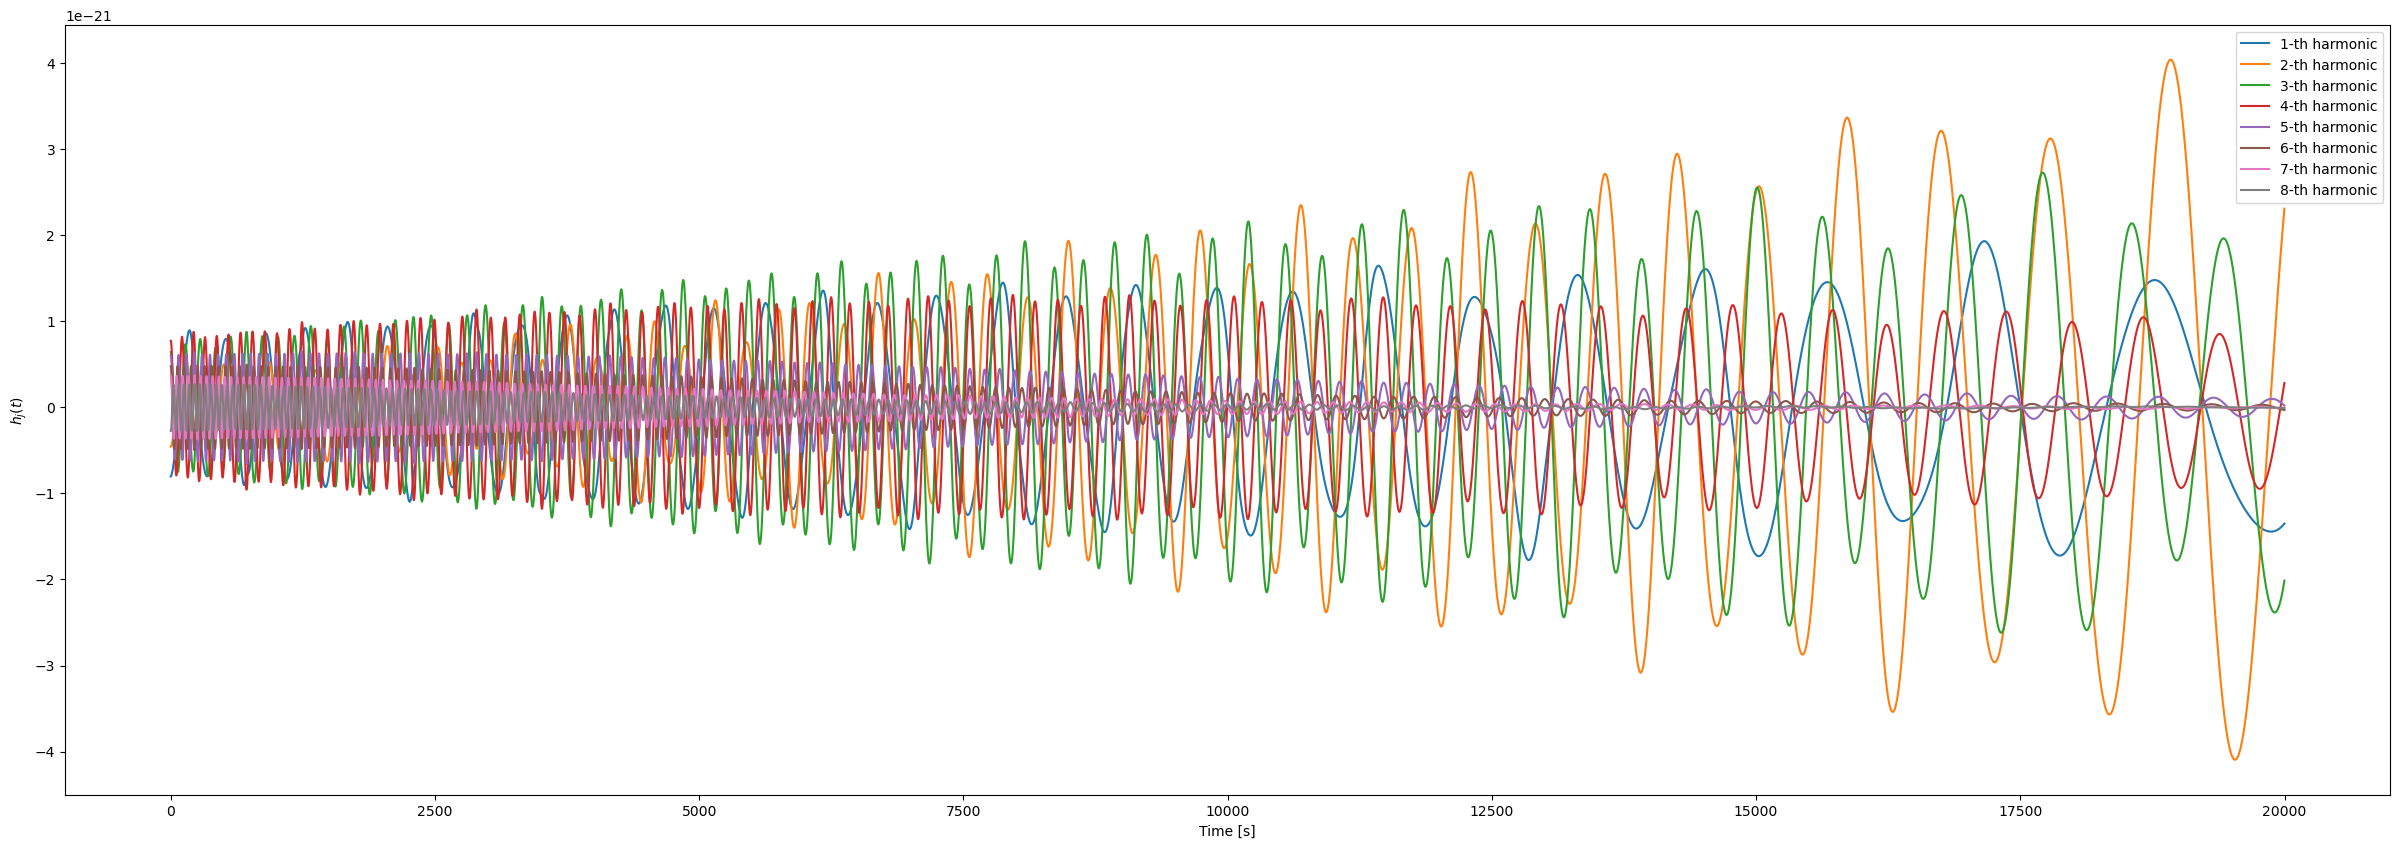

In [35]:
plt.figure(figsize=(30, 10))

for j_index, waveform in sorted_harmonics.items():
        plt.plot(waveform.real, label=f'{j_index}-th harmonic')
plt.ylabel('$h_j(t)$')
plt.xlabel('Time [s]')
plt.legend()
plt.show()

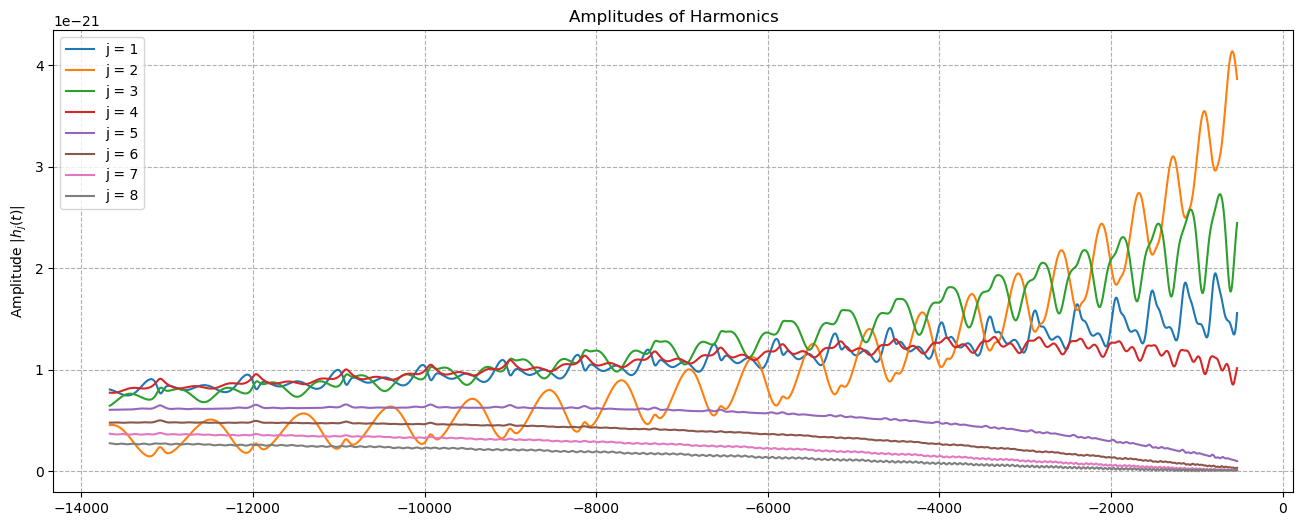

In [36]:
plt.figure(figsize=(16, 6))
for j_index, waveform in sorted_harmonics.items():
    amp = np.abs(waveform)
    plt.plot(t_val, amp, label=f'j = {j_index}')
plt.ylabel('Amplitude |$h_j(t)$|')
plt.title('Amplitudes of Harmonics')
plt.legend()
plt.grid(True, which="both", ls="--")

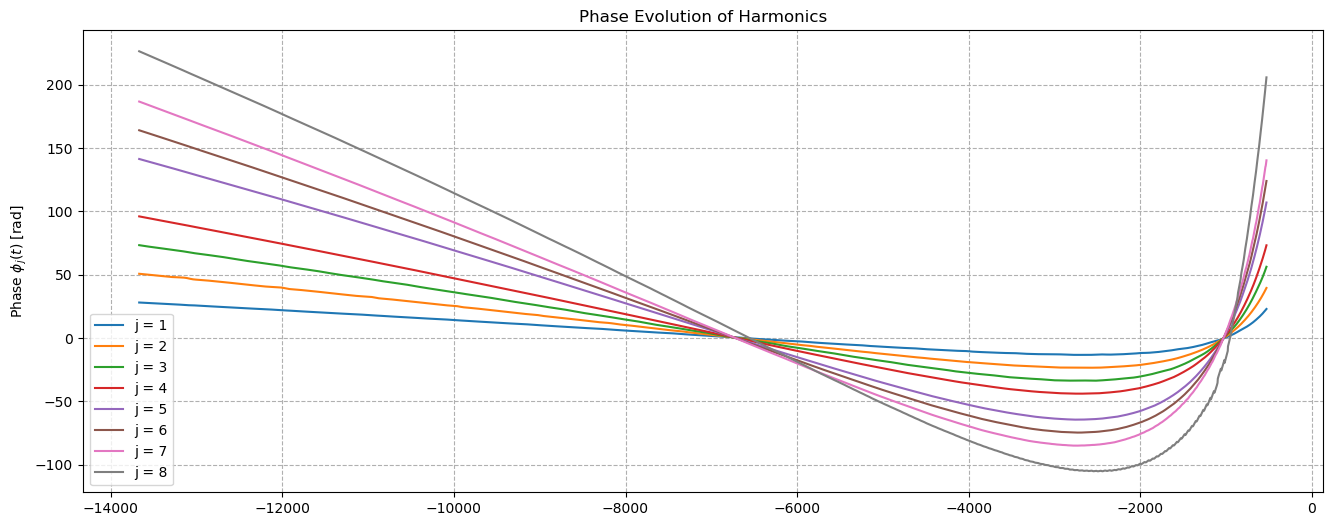

In [37]:
plt.figure(figsize=(16, 6))
for j_index, waveform in sorted_harmonics.items():
    phase = np.unwrap(np.angle(waveform))
    plt.plot(t_val, detrend(phase), label=f'j = {j_index}')
plt.ylabel('Phase $\phi_j(t)$ [rad]')
plt.title('Phase Evolution of Harmonics')
plt.legend()
plt.grid(True, which="both", ls="--")


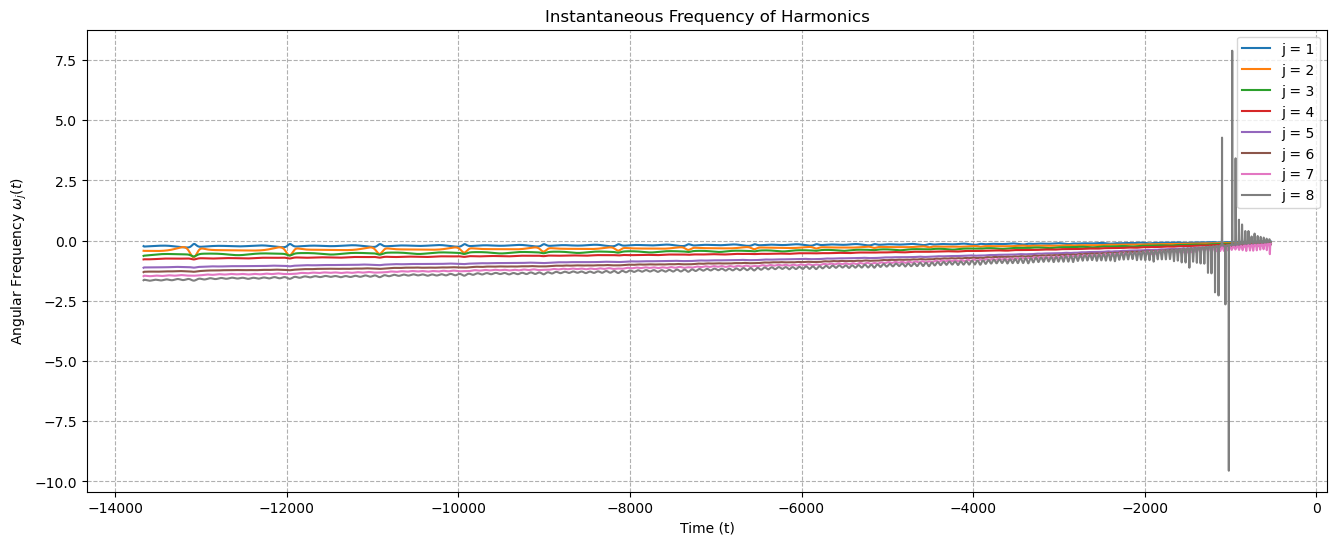

In [38]:
plt.figure(figsize=(16, 6))
for j_index, waveform in sorted_harmonics.items():
    phase = np.unwrap(np.angle(waveform))
    omega = np.gradient(phase, dt)
    plt.plot(t_val, omega, label=f'j = {j_index}')
plt.ylabel('Angular Frequency $\omega_j(t)$')
plt.title('Instantaneous Frequency of Harmonics')
plt.xlabel('Time (t)')
plt.legend()
plt.grid(True, which="both", ls="--")

In [39]:
def calculate_l2_error(h_original, h_recon):
    integrand_diff = np.abs(h_original - h_recon)**2
    integrand_orig = np.abs(h_original)**2
    numerator = np.sum(integrand_diff) * delta_t
    denominator = np.sum(integrand_orig) * delta_t
    return 0.5 * (numerator / denominator)

raw_basis_vectors = Vt[:5, :]
raw_errors = []

for i in range(50):
    original_waveform = X_waveform[i, :]
    
    coeffs_raw = np.dot(original_waveform, raw_basis_vectors.conj().T)
    recon_raw = np.dot(coeffs_raw, raw_basis_vectors)
    raw_errors.append(calculate_l2_error(original_waveform, recon_raw))

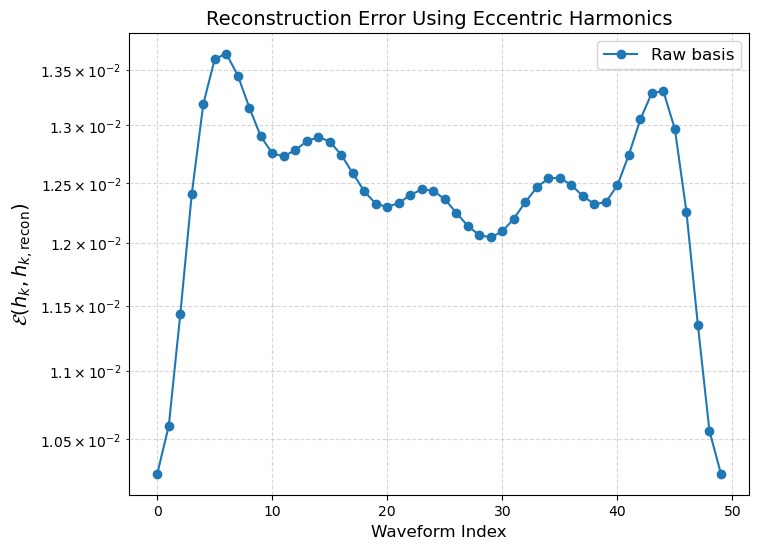

In [40]:
plt.figure(figsize=(8, 6))
plt.semilogy(range(50), raw_errors, 'o-', label='Raw basis', color='C0')
plt.xlabel('Waveform Index', fontsize=12)
plt.ylabel(r'$\mathcal{E}(h_k, h_{k, \text{recon}})$', fontsize=14)
plt.title('Reconstruction Error Using Eccentric Harmonics', fontsize=14)
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.legend(fontsize=12)
# plt.ylim(bottom=1e-6)
# plt.xlim(0, 120 - 1)
plt.show()